In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikitabisht/menstrual-cycle-data")

print("Path to dataset files:", path)

/Users/adwaitmahajan/miniconda3/envs/aster/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/adwaitmahajan/.cache/kagglehub/datasets/nikitabisht/menstrual-cycle-data/versions/1


In [2]:
import os

data_path = '/Users/adwaitmahajan/.cache/kagglehub/datasets/nikitabisht/menstrual-cycle-data/versions/1'
files = os.listdir(data_path)
print(files)

['FedCycleData071012 (2).csv']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [18]:
df = pd.read_csv(os.path.join(data_path, 'FedCycleData071012 (2).csv'), na_values=[" "])

In [22]:
df.head()

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1,0,1,0,29,27.33,17.0,12.0,12.0,...,9.0,NaN,NaN,2.0,7.0,7.0,1.0,1.0,0.0,21.254724
1,nfp8122,2,0,1,0,27,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nfp8122,3,0,1,0,29,NaN,15.0,14.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,nfp8122,4,0,1,0,27,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,nfp8122,5,0,1,0,28,NaN,16.0,12.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

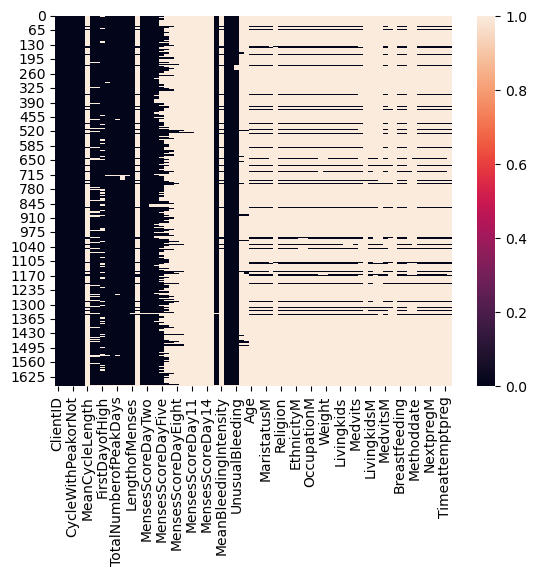

In [23]:
sns.heatmap(df.isna())

In [26]:
threshold = len(df) * 0.5
df.dropna(axis=1, thresh=threshold, inplace=True)

<Axes: >

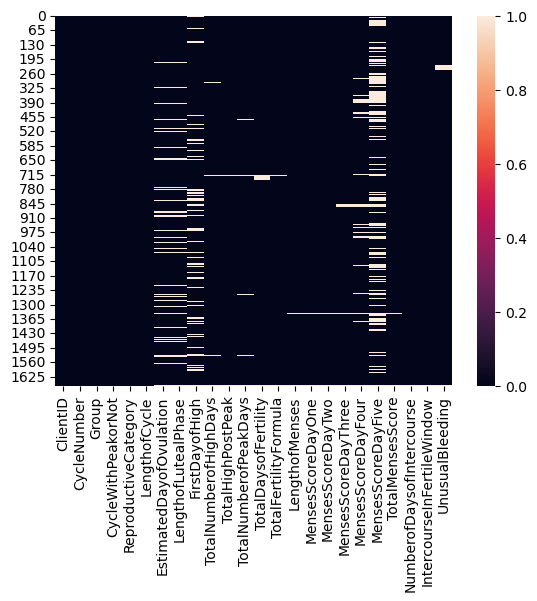

In [28]:
sns.heatmap(df.isna())

In [32]:
missing_percent = df.isna().mean() * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

MensesScoreDayFive            26.066066
FirstDayofHigh                15.495495
LengthofLutealPhase            9.069069
EstimatedDayofOvulation        9.009009
MensesScoreDayFour             5.225225
TotalDaysofFertility           1.861862
MensesScoreDayThree            1.501502
UnusualBleeding                1.201201
TotalNumberofPeakDays          0.960961
TotalNumberofHighDays          0.720721
LengthofMenses                 0.240240
MensesScoreDayTwo              0.240240
TotalMensesScore               0.240240
MensesScoreDayOne              0.240240
TotalHighPostPeak              0.180180
TotalFertilityFormula          0.120120
NumberofDaysofIntercourse      0.060060
IntercourseInFertileWindow     0.060060
dtype: float64


In [38]:
df.drop(axis=1, columns=['ClientID'], inplace=True)

In [48]:
df.drop(axis=1, columns=['MensesScoreDayFive'], inplace=True)

In [51]:
df_cleaned = df.fillna(df.median(numeric_only=True))

In [58]:
df_cleaned.isnull().sum()

CycleNumber                   0
Group                         0
CycleWithPeakorNot            0
ReproductiveCategory          0
LengthofCycle                 0
EstimatedDayofOvulation       0
LengthofLutealPhase           0
FirstDayofHigh                0
TotalNumberofHighDays         0
TotalHighPostPeak             0
TotalNumberofPeakDays         0
TotalDaysofFertility          0
TotalFertilityFormula         0
LengthofMenses                0
MensesScoreDayOne             0
MensesScoreDayTwo             0
MensesScoreDayThree           0
MensesScoreDayFour            0
TotalMensesScore              0
NumberofDaysofIntercourse     0
IntercourseInFertileWindow    0
UnusualBleeding               0
dtype: int64

In [59]:
from pathlib import Path

output_dir = Path("data") / "Main Data"
output_dir.mkdir(parents=True, exist_ok=True)

In [60]:
output_path = output_dir / "cleaned_cycle_data.csv"
df_cleaned.to_csv(output_path, index=False)

print(f"Saved cleaned data to: {output_path}")

Saved cleaned data to: data/Main Data/cleaned_cycle_data.csv


In [61]:
df_cleaned

,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,TotalNumberofHighDays,TotalHighPostPeak,...,TotalFertilityFormula,LengthofMenses,MensesScoreDayOne,MensesScoreDayTwo,MensesScoreDayThree,MensesScoreDayFour,TotalMensesScore,NumberofDaysofIntercourse,IntercourseInFertileWindow,UnusualBleeding
0,1,0,1,0,29,17.0,12.0,12.0,5.0,0.0,...,15.0,5.0,3.0,3.0,2.0,1.0,10.0,5.0,1.0,0.0
1,2,0,1,0,27,15.0,12.0,13.0,2.0,0.0,...,13.0,5.0,3.0,3.0,2.0,1.0,10.0,6.0,1.0,0.0
2,3,0,1,0,29,15.0,14.0,11.0,1.0,0.0,...,13.0,5.0,3.0,3.0,2.0,1.0,10.0,5.0,1.0,0.0
3,4,0,1,0,27,15.0,12.0,13.0,2.0,0.0,...,13.0,5.0,3.0,3.0,3.0,2.0,12.0,3.0,0.0,0.0
4,5,0,1,0,28,16.0,12.0,12.0,4.0,0.0,...,14.0,5.0,3.0,3.0,2.0,2.0,11.0,5.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1660,7,1,1,0,29,19.0,10.0,13.0,5.0,0.0,...,15.0,8.0,2.0,3.0,3.0,2.0,15.0,8.0,0.0,1.0
1661,8,1,1,0,28,17.0,11.0,12.0,3.0,0.0,...,13.0,6.0,3.0,3.0,2.0,1.0,11.0,11.0,1.0,0.0
1662,9,1,1,0,28,16.0,12.0,11.0,4.0,0.0,...,12.0,5.0,3.0,2.0,2.0,1.0,9.0,7.0,0.0,0.0
1663,10,1,1,1,40,27.0,13.0,13.0,13.0,0.0,...,24.0,6.0,2.0,3.0,3.0,2.0,12.0,3.0,0.0,0.0


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, 'CycleNumber'),
  Text(1, 0, 'CycleWithPeakorNot'),
  Text(2, 0, 'MensesScoreDayTwo'),
  Text(3, 0, 'MensesScoreDayThree'),
  Text(4, 0, 'Group'),
  Text(5, 0, 'TotalHighPostPeak'),
  Text(6, 0, 'MensesScoreDayOne'),
  Text(7, 0, 'TotalNumberofPeakDays'),
  Text(8, 0, 'MensesScoreDayFour'),
  Text(9, 0, 'ReproductiveCategory'),
  Text(10, 0, 'IntercourseInFertileWindow'),
  Text(11, 0, 'TotalMensesScore'),
  Text(12, 0, 'NumberofDaysofIntercourse'),
  Text(13, 0, 'TotalNumberofHighDays'),
  Text(14, 0, 'LengthofMenses'),
  Text(15, 0, 'UnusualBleeding'),
  Text(16, 0, 'TotalDaysofFertility'),
  Text(17, 0, 'LengthofLutealPhase'),
  Text(18, 0, 'FirstDayofHigh'),
  Text(19, 0, 'TotalFertilityFormula'),
  Text(20, 0, 'EstimatedDayofOvulation')])

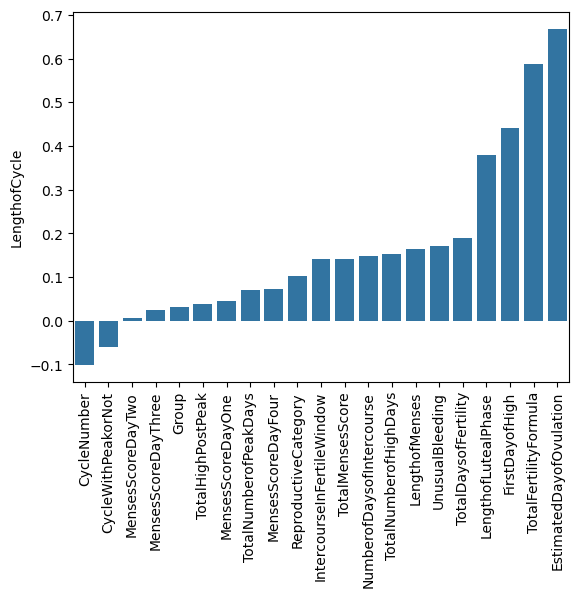

In [63]:
sns.barplot(df_cleaned.corr()['LengthofCycle'].sort_values(ascending=True)[:-1])
plt.xticks(rotation=90)